# ASL Dynamic Signs — LSTM Baseline

Este notebook treina um modelo LSTM para reconhecimento de sinais dinâmicos em ASL usando o dataset PopSign do Kaggle (`asl-signs`).

**Dataset esperado:**
```
asl-signs/
├── train.csv
├── sign_to_prediction_index_map.json
└── train_landmarks/
    └── *.parquet
```

## 1. Imports & Configuração

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Reprodutibilidade ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Configuração do Device ---
def get_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    
    # Testar se a GPU é compatível (evitar erro de "no kernel image" em GPUs antigas)
    try:
        # Tenta criar um pequeno tensor e movê-lo para a GPU
        test_tensor = torch.zeros(1).cuda()
        return torch.device('cuda')
    except Exception as e:
        print(f"Aviso: GPU detectada mas não é compatível com esta versão do PyTorch.")
        print(f"Erro: {e}")
        print("A usar CPU como alternativa...")
        return torch.device('cpu')

DEVICE = get_device()
print(f'Device: {DEVICE}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/luiscunha/miniconda3/envs/torch-gpu/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/luiscunha/miniconda3/envs/torch-gpu/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/luiscunha/miniconda3/envs/torch-gpu/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/luiscunha/miniconda3/envs/torch-gpu/lib/python3.10/site-packages/traitlets/con

Device: cuda


In [ ]:
# --- Caminhos ---
DATA_DIR      = Path('/home/luiscunha/Downloads/asl-signs')          
LANDMARK_DIR  = DATA_DIR / 'train_landmark_files'
TRAIN_CSV     = DATA_DIR / 'train.csv'
LABEL_MAP     = DATA_DIR / 'sign_to_prediction_index_map.json'

# --- Hiperparâmetros ---
MAX_FRAMES    = 64       # frames por sequência (pad/truncate)
BATCH_SIZE    = 64
NUM_EPOCHS    = 30
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
VAL_SPLIT     = 0.1

# Landmarks a usar (130 melhores descobertos pelos vencedores do Kaggle)
# face: lábios, nariz, olhos | mãos: esquerda e direita | pose: parcial
USE_TYPES     = ['left_hand', 'right_hand', 'pose']   # exclui face para simplicidade

## 2. Carregamento de Dados

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
print(f'Total de sequências: {len(train_df)}')
print(f'Total de sinais únicos: {train_df["sign"].nunique()}')
print(f'\nPrimeiras linhas:')
train_df.head()

NUM_TEST_CLASSES = 50
selected_signs = train_df['sign'].unique()[:NUM_TEST_CLASSES]

train_df = train_df[train_df['sign'].isin(selected_signs)].reset_index(drop=True)

Total de sequências: 94477
Total de sinais únicos: 250

Primeiras linhas:


In [4]:
# Carregar mapa de labels
#with open(LABEL_MAP, 'r') as f:
#    sign2idx = json.load(f)

#idx2sign = {v: k for k, v in sign2idx.items()}

sign2idx = {sign: i for i, sign in enumerate(selected_signs)}
idx2sign = {i: sign for sign, i in sign2idx.items()}
NUM_CLASSES = len(sign2idx)
print(f"Modo de teste ativado: {NUM_CLASSES} classes selecionadas.")
print(f"Total de sequências filtradas: {len(train_df)}")

NUM_CLASSES = len(sign2idx)
print(f'Número de classes: {NUM_CLASSES}')
print(f'Exemplos: {list(sign2idx.items())[:5]}')

Modo de teste ativado: 50 classes selecionadas.
Total de sequências filtradas: 18808
Número de classes: 50
Exemplos: [('blow', 0), ('wait', 1), ('cloud', 2), ('bird', 3), ('owie', 4)]


Amostras por sinal — min: 299, max: 405, média: 376.2


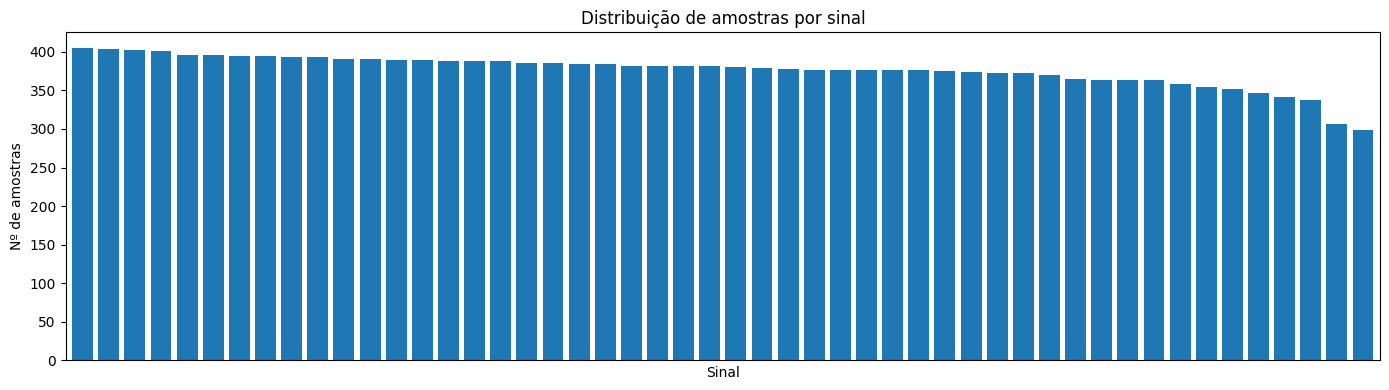

In [5]:
# Distribuição de amostras por sinal
counts = train_df['sign'].value_counts()
print(f'Amostras por sinal — min: {counts.min()}, max: {counts.max()}, média: {counts.mean():.1f}')

plt.figure(figsize=(14, 4))
counts.plot(kind='bar', width=0.8)
plt.title('Distribuição de amostras por sinal')
plt.xlabel('Sinal')
plt.ylabel('Nº de amostras')
plt.xticks([])
plt.tight_layout()
plt.show()

## 3. Pré-processamento

In [6]:
def load_landmarks(part_id, seq_id, landmark_dir, use_types, max_frames):
    path = landmark_dir / f'{part_id}' / f'{seq_id}.parquet'
    
    # Define expected dimension (75 landmarks * 3 coordinates = 225)
    # It's better to hardcode or calculate this to avoid the "1-dim" bug
    expected_dim = (21 + 21 + 33) * 3 if 'pose' in use_types else 42 * 3
    
    try:
        df = pd.read_parquet(path)
        df = df[df['type'].isin(use_types)]
        
        if df.empty:
            return np.zeros((max_frames, expected_dim), dtype=np.float32), 0

        # 1. Pivot to get (frames, landmarks * 3)
        pivot = df.pivot(index='frame', columns=['type', 'landmark_index'], values=['x', 'y', 'z'])
        
        # 2. IMPORTANT: Interleave coordinates so it's [x, y, z, x, y, z...] 
        # This makes sure arr[:, 0::3] is always X
        pivot = pivot.reorder_levels([1, 2, 0], axis=1).sort_index(axis=1)
        
        arr = pivot.values.astype(np.float32)
        arr = np.nan_to_num(arr, nan=0.0)
        actual_len = len(arr)

    except Exception as e:
        # If anything fails, return zeros with the CORRECT dimension
        return np.zeros((max_frames, expected_dim), dtype=np.float32), 0

    # 3. Normalization (now safe because of the interleaving above)
    nonzero = arr[arr != 0]
    if len(nonzero) > 0:
        arr_x = arr[:, 0::3]
        arr_y = arr[:, 1::3]
        cx = arr_x[arr_x != 0].mean() if (arr_x != 0).any() else 0.5
        cy = arr_y[arr_y != 0].mean() if (arr_y != 0).any() else 0.5
        arr[:, 0::3] -= cx
        arr[:, 1::3] -= cy

    # 4. Pad or truncate
    T, F = arr.shape
    if T < max_frames:
        pad = np.zeros((max_frames - T, F), dtype=np.float32)
        arr = np.concatenate([arr, pad], axis=0)
    else:
        arr = arr[:max_frames]
        actual_len = max_frames

    return arr, actual_len


In [7]:
# Verificar dimensão do input
participant_id =  train_df['participant_id'].iloc[0] 
sample_id = train_df['sequence_id'].iloc[0]
sample, actual_len = load_landmarks(participant_id, sample_id, LANDMARK_DIR, USE_TYPES, MAX_FRAMES)
INPUT_DIM = sample.shape[1]
print(f'Input dim por frame: {INPUT_DIM}')
print(f'Shape do tensor: {sample.shape}')  # (MAX_FRAMES, INPUT_DIM)
print(f'Frames reais: {actual_len}')

Input dim por frame: 225
Shape do tensor: (64, 225)
Frames reais: 23


## 4. Dataset & DataLoader

In [9]:
class ASLDataset(Dataset):
    def __init__(self, df, landmark_dir, sign2idx, use_types, max_frames, augment=False):
        self.df           = df.reset_index(drop=True)
        self.landmark_dir = Path(landmark_dir)
        self.sign2idx     = sign2idx
        self.use_types    = use_types
        self.max_frames   = max_frames
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def _augment(self, x):
        if random.random() < 0.5:
            x = x.clone()
            x[:, 0::3] *= -1
        if random.random() < 0.5:
            x = x + torch.randn_like(x) * 0.01
        return x

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        # Correção: passar participant_id e sequence_id
        arr, actual_len = load_landmarks(row['participant_id'], row['sequence_id'], 
                                         self.landmark_dir, self.use_types, self.max_frames)
        
        x      = torch.tensor(arr, dtype=torch.float32)
        y      = self.sign2idx[row['sign']]

        if self.augment:
            x = self._augment(x)

        # Máscara de padding (True = posição de padding)
        pad_mask  = torch.zeros(self.max_frames, dtype=torch.bool)
        pad_mask[actual_len:] = True

        return x, torch.tensor(y, dtype=torch.long), pad_mask


In [10]:
# Split treino/validação estratificado por sinal
train_split, val_split = train_test_split(
    train_df,
    test_size=VAL_SPLIT,
    stratify=train_df['sign'],
    random_state=SEED
)

print(f'Treino: {len(train_split)} | Validação: {len(val_split)}')

train_ds = ASLDataset(train_split, LANDMARK_DIR, sign2idx, USE_TYPES, MAX_FRAMES, augment=True)
val_ds   = ASLDataset(val_split,   LANDMARK_DIR, sign2idx, USE_TYPES, MAX_FRAMES, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'Batches treino: {len(train_loader)} | Batches validação: {len(val_loader)}')

Treino: 16927 | Validação: 1881
Batches treino: 265 | Batches validação: 30


## 5. Modelo LSTM

In [11]:
class ASLLSTMModel(nn.Module):
    """
    Modelo LSTM bidirecional para reconhecimento de sinais ASL.

    Arquitetura:
        Input → Projeção linear → BiLSTM (N camadas) → Dropout
        → Concat(último estado forward + backward) → Classificador
    """
    def __init__(
        self,
        input_dim,
        num_classes,
        hidden_dim=256,
        num_layers=2,
        dropout=0.3,
        bidirectional=True
    ):
        super().__init__()
        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.num_dirs      = 2 if bidirectional else 1

        # Projeção inicial para espaço de dimensão fixa
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM bidirecional
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
            batch_first=True
        )

        # Classificador final
        lstm_out_dim = hidden_dim * self.num_dirs
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x, pad_mask=None):
        # x: (batch, frames, features)
        x = self.input_proj(x)           # (batch, frames, hidden_dim)

        # Packed sequence para ignorar padding no LSTM
        if pad_mask is not None:
            lengths = (~pad_mask).sum(dim=1).cpu().clamp(min=1)
            x_packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False
            )
            out_packed, (h_n, _) = self.lstm(x_packed)
        else:
            _, (h_n, _) = self.lstm(x)

        # h_n: (num_layers * num_dirs, batch, hidden_dim)
        # Pegar nos estados finais da última camada
        if self.bidirectional:
            # Concatenar forward e backward da última camada
            h_fwd = h_n[-2]  # forward
            h_bwd = h_n[-1]  # backward
            h = torch.cat([h_fwd, h_bwd], dim=-1)  # (batch, hidden*2)
        else:
            h = h_n[-1]  # (batch, hidden)

        return self.classifier(h)  # (batch, num_classes)


# Instanciar modelo
model = ASLLSTMModel(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total_params:,}')
print(model)

Parâmetros treináveis: 2,976,306
ASLLSTMModel(
  (input_proj): Sequential(
    (0): Linear(in_features=225, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=512, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=50, bias=True)
  )
)


## 6. Treino

In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: reduz LR quando a val_loss estagna
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for x, y, mask in tqdm(loader, desc='Treino', leave=False):
        x, y, mask = x.to(device), y.to(device), mask.to(device)

        optimizer.zero_grad()
        logits = model(x, pad_mask=mask)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        preds          = logits.argmax(dim=-1)
        total_loss    += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total         += x.size(0)

    return total_loss / total, total_correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0

    for x, y, mask in tqdm(loader, desc='Validação', leave=False):
        x, y, mask = x.to(device), y.to(device), mask.to(device)

        logits = model(x, pad_mask=mask)
        loss   = criterion(logits, y)

        preds          = logits.argmax(dim=-1)
        total_loss    += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total         += x.size(0)

    return total_loss / total, total_correct / total

In [13]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_model_path = 'best_lstm_model.pt'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion,           DEVICE)

    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        marker = ' ✓ saved'
    else:
        marker = ''

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{marker}')

print(f'\nMelhor Val Acc: {best_val_acc:.4f}')

Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss: 3.9097 Acc: 0.0223 | Val Loss: 3.8543 Acc: 0.0340 ✓ saved


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

...

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 1.4141 Acc: 0.7786 | Val Loss: 1.9258 Acc: 0.6215


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 1.3813 Acc: 0.7918 | Val Loss: 1.8629 Acc: 0.6539 ✓ saved

Melhor Val Acc: 0.6539


## 7. Resultados

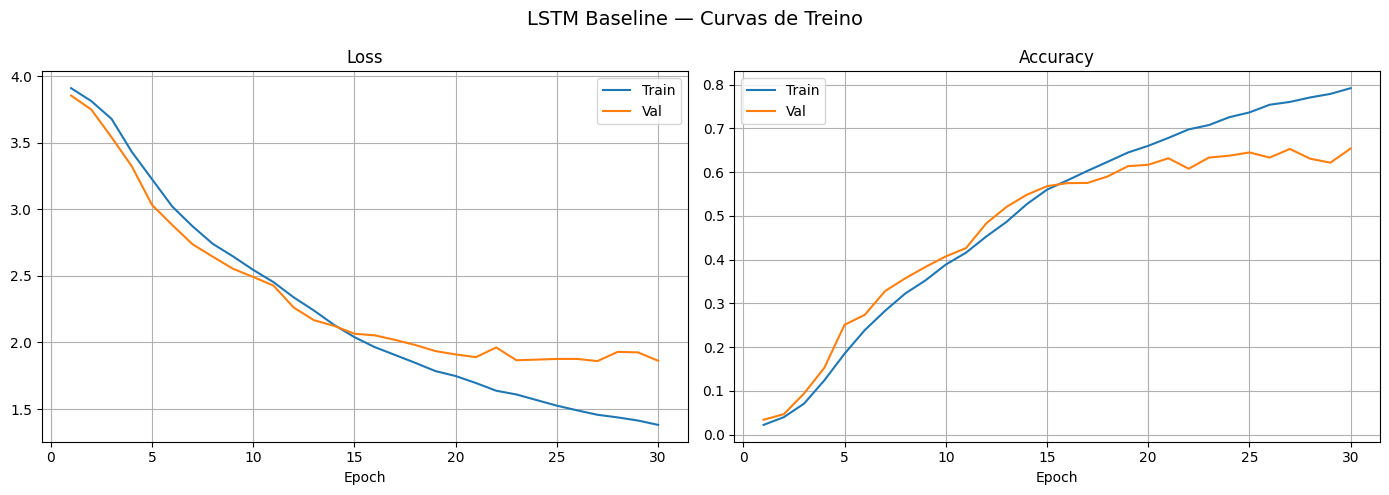

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('LSTM Baseline — Curvas de Treino', fontsize=14)
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()

In [15]:
# Carregar melhor modelo e avaliar em detalhe
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y, mask in tqdm(val_loader, desc='Avaliação final'):
        x, mask = x.to(DEVICE), mask.to(DEVICE)
        logits  = model(x, pad_mask=mask)
        preds   = logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(y.tolist())

# Relatório por classe (top-10 piores)
from sklearn.metrics import accuracy_score
final_acc = accuracy_score(all_labels, all_preds)
print(f'Accuracy final (melhor modelo): {final_acc:.4f}')

report = classification_report(
    all_labels, all_preds,
    target_names=[idx2sign[i] for i in range(NUM_CLASSES)],
    output_dict=True
)
report_df = pd.DataFrame(report).T
print('\n10 sinais com menor F1:')
print(report_df.iloc[:-3].sort_values('f1-score').head(10)[['precision', 'recall', 'f1-score', 'support']])

Avaliação final:   0%|          | 0/30 [00:00<?, ?it/s]

Accuracy final (melhor modelo): 0.6539

10 sinais com menor F1:
        precision    recall  f1-score  support
empty    0.478261  0.297297  0.366667     37.0
vacuum   0.333333  0.516129  0.405063     31.0
cheek    0.451613  0.378378  0.411765     37.0
yellow   0.384615  0.526316  0.444444     38.0
fall     0.447368  0.447368  0.447368     38.0
there    0.500000  0.416667  0.454545     36.0
go       0.551724  0.410256  0.470588     39.0
puzzle   0.560000  0.411765  0.474576     34.0
owie     0.485714  0.472222  0.478873     36.0
finger   0.566667  0.447368  0.500000     38.0


In [16]:
# Guardar modelo final
torch.save({
    'model_state_dict': model.state_dict(),
    'sign2idx': sign2idx,
    'idx2sign': idx2sign,
    'input_dim': INPUT_DIM,
    'num_classes': NUM_CLASSES,
    'max_frames': MAX_FRAMES,
    'use_types': USE_TYPES,
    'val_acc': best_val_acc
}, 'asl_lstm_final.pt')

print('Modelo guardado em asl_lstm_final.pt')

Modelo guardado em asl_lstm_final.pt
